In [1]:
from src import clustering, graph_utils, plotting
import spatialdata as sd
import os 
sdata = sd.read_zarr("zarr/debug_dataset.zarr")
adata = sdata.tables["table"]

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


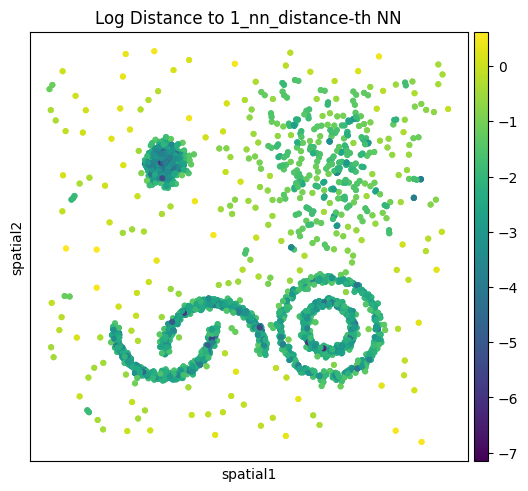

In [2]:
K = 1
graph_utils.get_distances(adata, k=1, log=True)
plotting.plot_knn_distance(adata, distance_key="1_nn_distance")

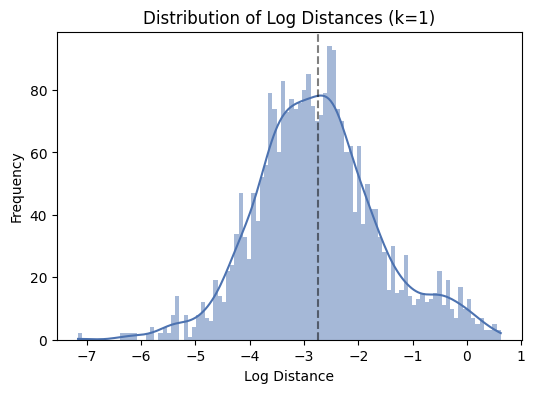

In [3]:
plotting.plot_knn_histogram(adata, k=1, bins=100)

In [4]:
results = clustering.fit_gmm(adata, distance_key="1_nn_distance", k_range=range(1,10))
# Some functionality missing like multiple inits

Fitted GMM with k=1
Fitted GMM with k=2
Fitted GMM with k=3
Fitted GMM with k=4
Fitted GMM with k=5
Fitted GMM with k=6
Fitted GMM with k=7
Fitted GMM with k=8
Fitted GMM with k=9


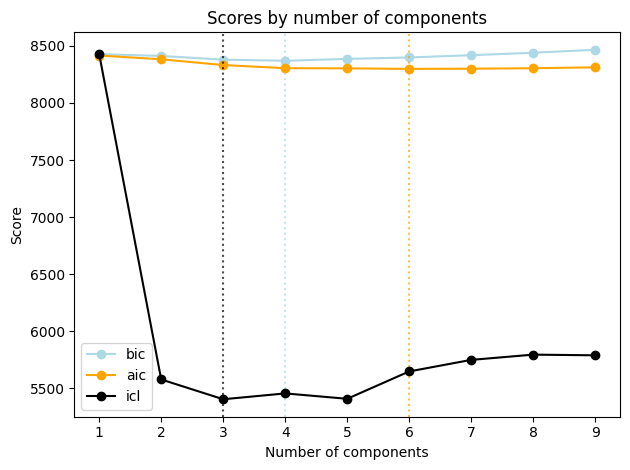

In [5]:
plotting.plot_scores(results)

In [6]:
best_model_icl = clustering.choose_component(results, criterion="icl", delta_bic_threshold=10.0)
best_model_bic = clustering.choose_component(results, criterion="bic", delta_bic_threshold=10.0)

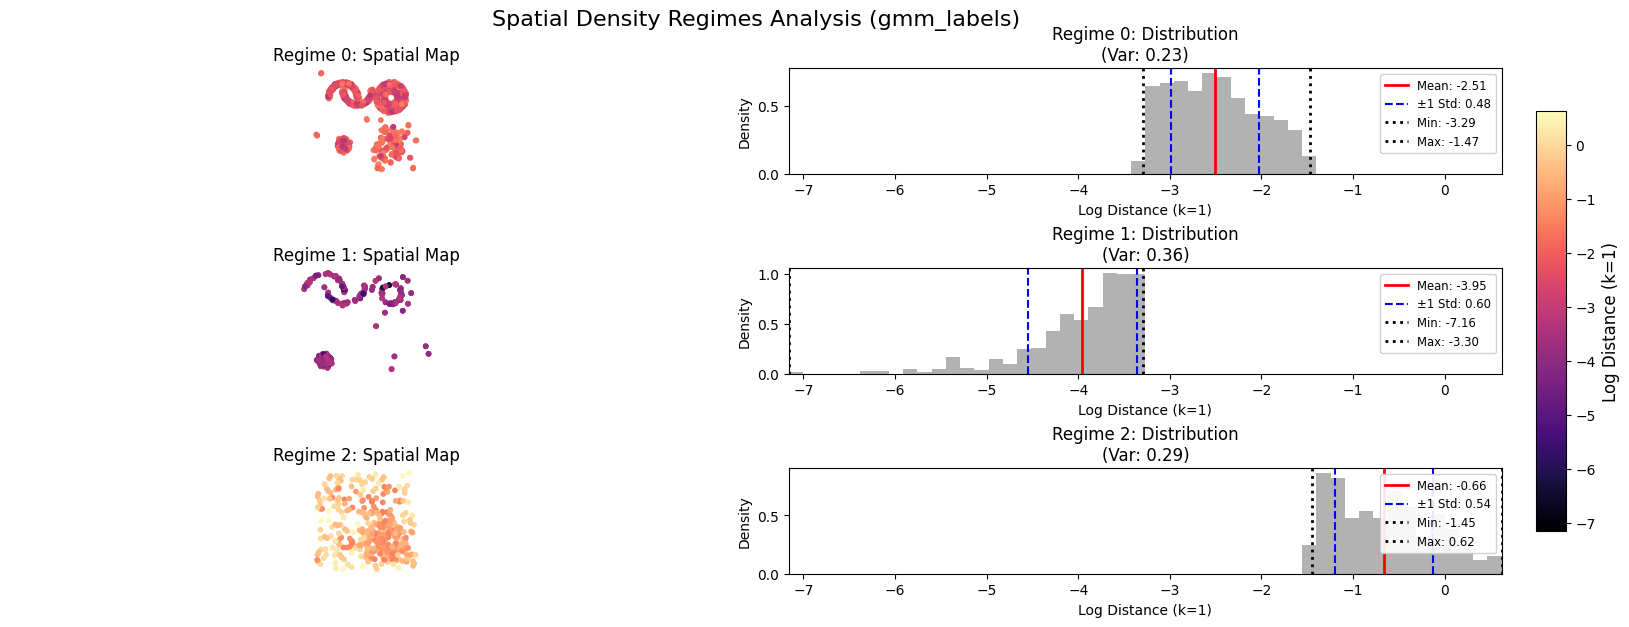

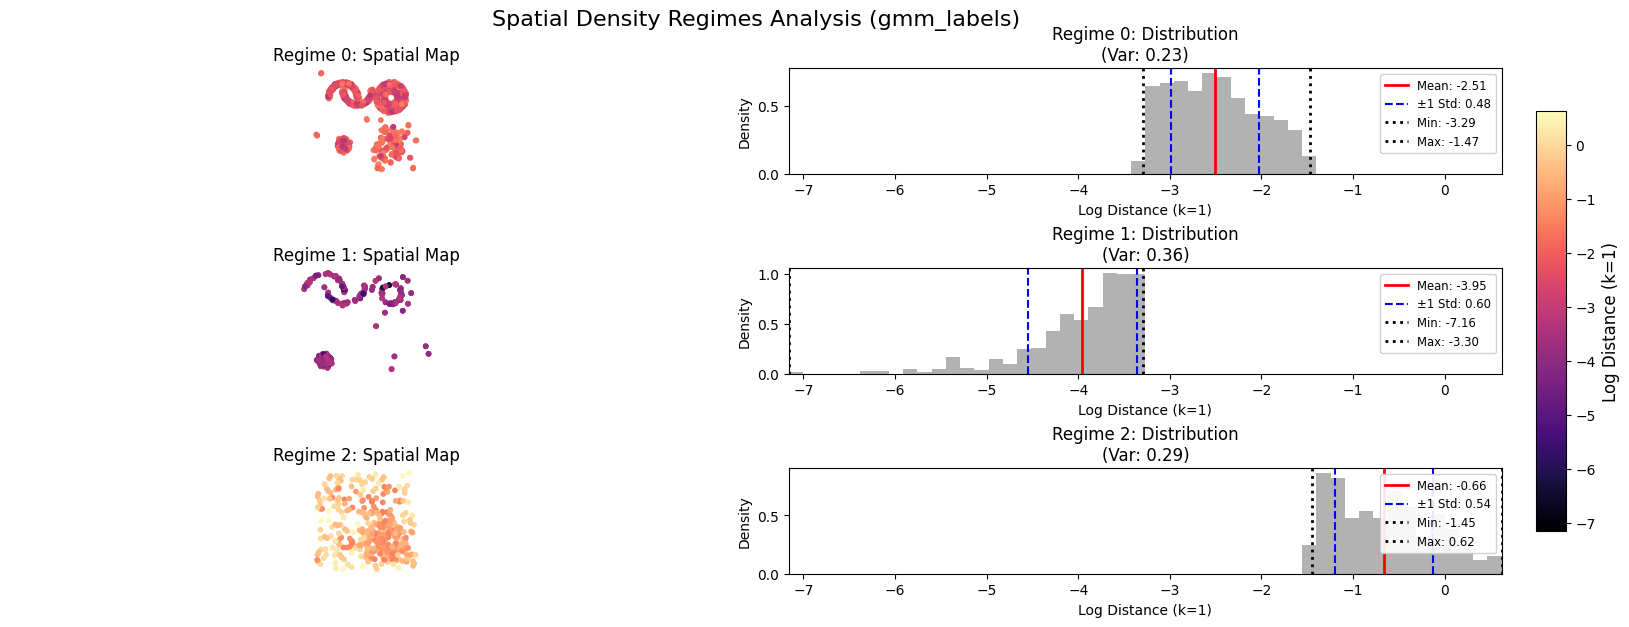

In [8]:
adata.obs["gmm_labels"] = best_model_icl["labels"]
adata.obs["gmm_labels"] = adata.obs["gmm_labels"].astype("category") 
plotting.plot_knn_by_regime(
    adata, 
    labels_key="gmm_labels", 
    k=1,             # Use k=1 distances
    size=10,         # Adjust dot size based on your data density
    cmap="magma",    # 'magma' is often good for density (dark = dense, bright = sparse)
    figsize=(15, 6)  # Force a specific figure size if the auto-calc isn't perfect
)

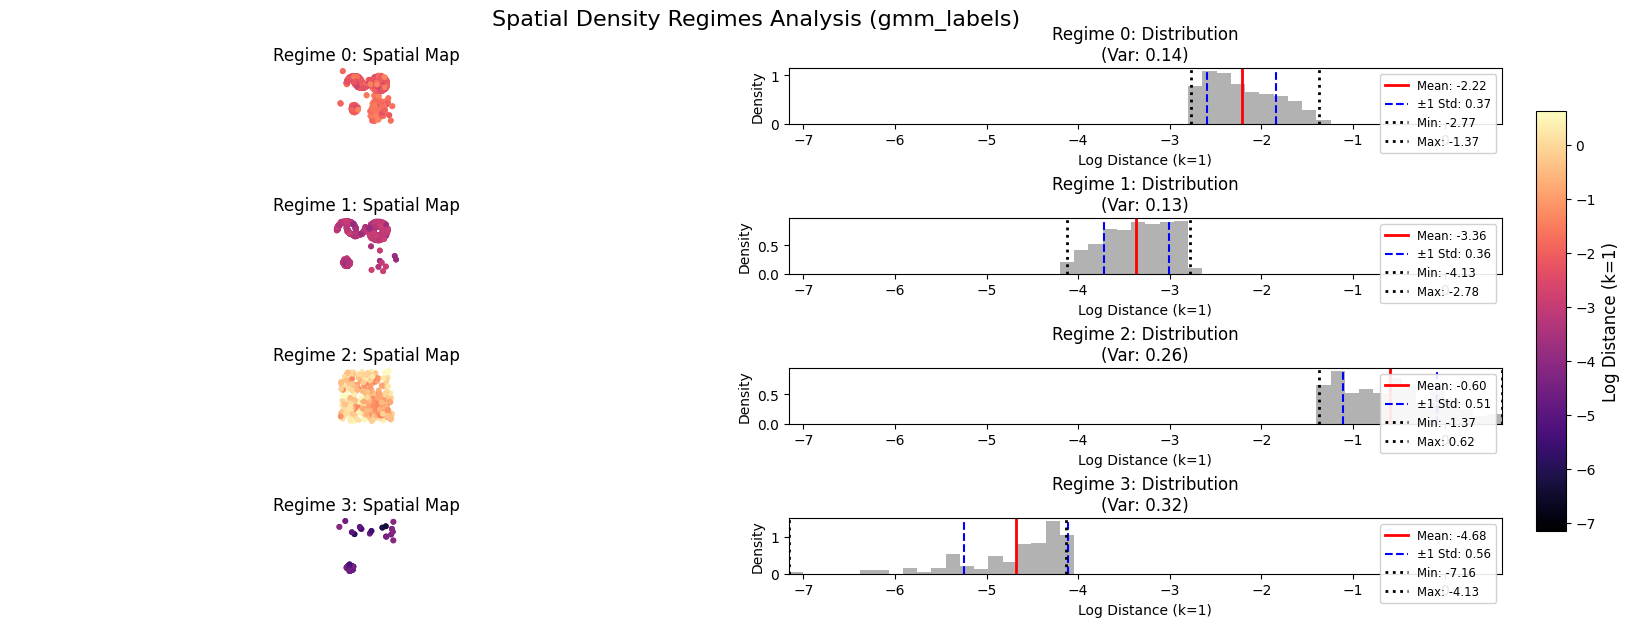

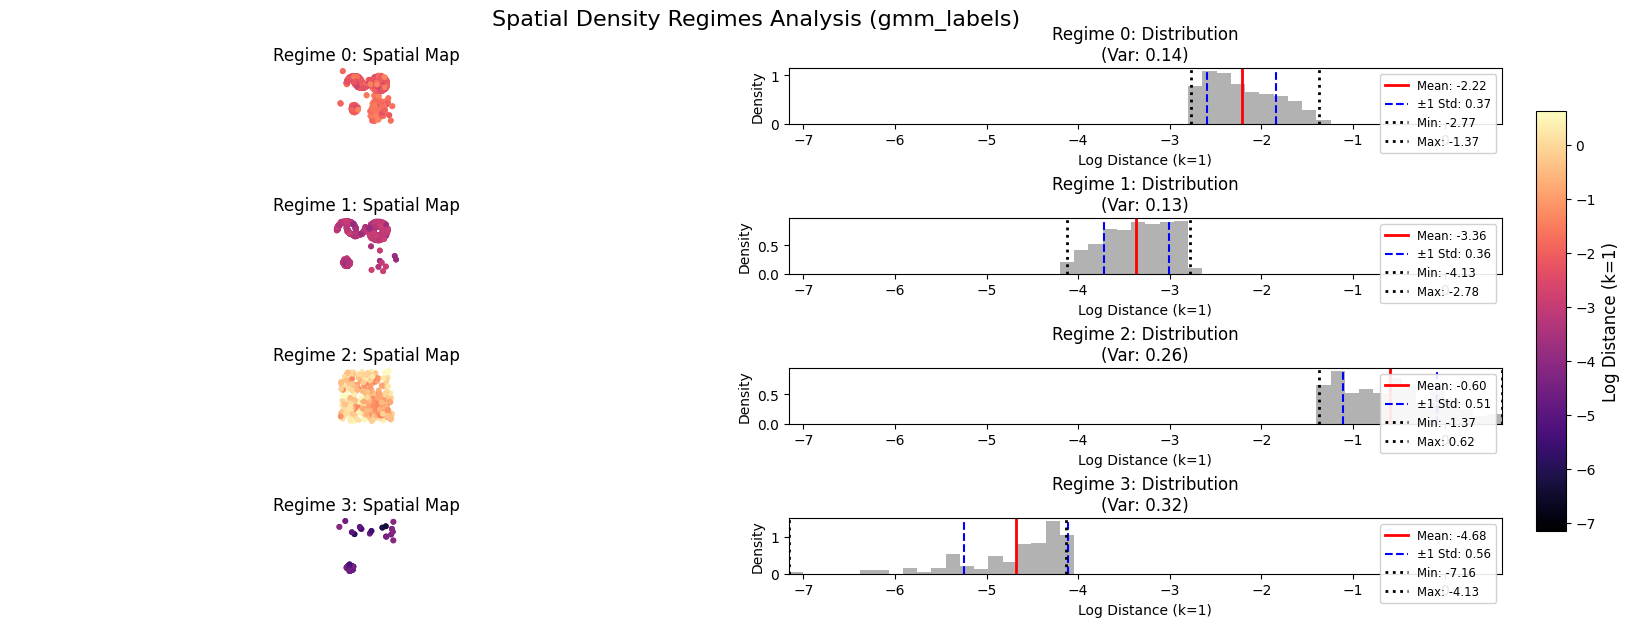

In [9]:
adata.obs["gmm_labels"] = best_model_bic["labels"]
adata.obs["gmm_labels"] = adata.obs["gmm_labels"].astype("category") 
plotting.plot_knn_by_regime(
    adata, 
    labels_key="gmm_labels", 
    k=1,             # Use k=1 distances
    size=10,         # Adjust dot size based on your data density
    cmap="magma",    # 'magma' is often good for density (dark = dense, bright = sparse)
    figsize=(15, 6)  # Force a specific figure size if the auto-calc isn't perfect
)

In [10]:
graph_utils.get_neighbors(adata, type="delaunay")

In [11]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

def plot_pruned_connections(
    adata, 
    gmm_key, 
    basis="spatial", 
    prune_by="label", 
    distance_key=None, 
    n_std=2.0, 
    point_size=5,
    mode="comparison",
    ax=None,
    figsize=(16, 8)
):
    """
    Visualizes graph pruning.
    If prune_by="distance", compares log(spatial_distances) vs log-thresholds.
    """
    
    # --- 1. Data Retrieval ---
    if f"X_{basis}" in adata.obsm:
        coords = adata.obsm[f"X_{basis}"]
    elif basis in adata.obsm:
        coords = adata.obsm[basis]
    else:
        raise KeyError(f"Could not find coordinates in adata.obsm['{basis}']")

    adj_matrix = adata.obsp["spatial_distances"].tocoo()
    sources = adj_matrix.row
    targets = adj_matrix.col
    weights = adj_matrix.data # These are linear distances
    
    # --- 2. Determine Edges to Keep ---
    labels = adata.obs[gmm_key].values

    if prune_by == "label":
        edge_is_kept = labels[sources] == labels[targets]

    elif prune_by == "distance":
        if distance_key is None:
            raise ValueError("Must provide 'distance_key' when prune_by='distance'")
            
        # Stats on LOG values
        stats = adata.obs.groupby(gmm_key, observed=False)[distance_key].agg(['mean', 'std'])
        stats['std'] = stats['std'].fillna(0)
        
        # Calc LOG threshold
        stats['log_threshold'] = stats['mean'] + (n_std * stats['std'])
        
        # Map to cells
        mapping_dict = stats['log_threshold'].to_dict()
        cell_thresholds = adata.obs[gmm_key].map(mapping_dict).astype(float).values
        
        # Log the graph weights
        log_weights = np.log(weights + 1e-12)
        
        # Compare Log Weights vs Log Thresholds
        thresholds_per_edge = cell_thresholds[sources]
        edge_is_kept = log_weights <= thresholds_per_edge
        
    else:
        raise ValueError(f"Unknown pruning strategy: {prune_by}")

    # --- 3. Build Segments ---
    start_points = coords[sources]
    end_points = coords[targets]
    segments = np.stack((start_points, end_points), axis=1)

    kept_segments = segments[edge_is_kept]
    pruned_segments = segments[~edge_is_kept]
    
    n_kept = len(kept_segments)
    n_pruned = len(pruned_segments)

    # --- 4. Plotting ---
    def draw_graph(axis, show_pruned=True, title=""):
        axis.scatter(coords[:, 0], coords[:, 1], c=labels, s=point_size, cmap='tab20', zorder=10)
        
        lc_kept = LineCollection(kept_segments, colors='lightgray', linewidths=0.5, alpha=0.5, zorder=1)
        axis.add_collection(lc_kept)
        
        if show_pruned:
            lc_pruned = LineCollection(pruned_segments, colors='red', linewidths=1.0, alpha=0.8, zorder=5)
            axis.add_collection(lc_pruned)
            
        axis.set_title(title)
        axis.axis('equal')
        axis.axis('off')

    if mode == "comparison":
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        draw_graph(ax1, show_pruned=True, title=f"Candidates (Red)\nPruned: {n_pruned}")
        draw_graph(ax2, show_pruned=False, title=f"Final Graph\nKept: {n_kept}")
        return fig, (ax1, ax2)
    else:
        if ax is None: fig, ax = plt.subplots(figsize=(8, 8))
        show_p = (mode == "highlight")
        draw_graph(ax, show_pruned=show_p, title=f"Graph ({mode})")
        return ax

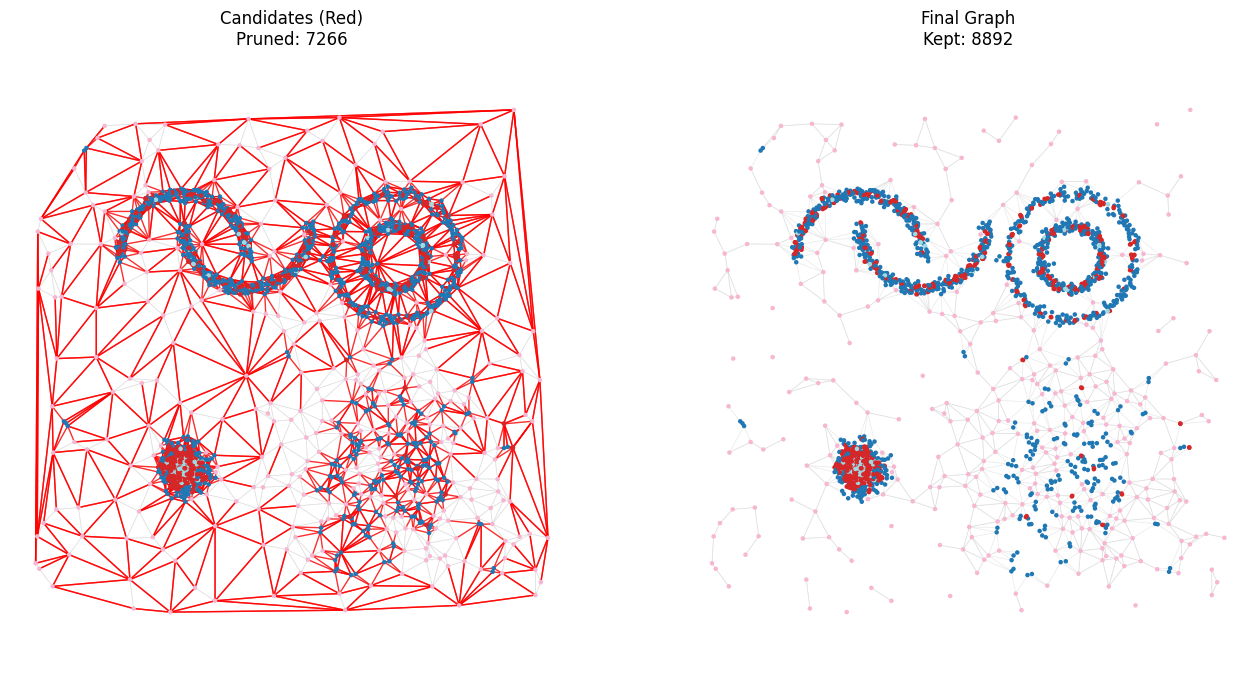

In [16]:
# 1. Compute neighbors (creates 'spatial_connectivities')
graph_utils.get_neighbors(adata, type="delaunay")

# 2. Visualize what WILL be pruned (Must run BEFORE pruning!)
# Visualize Distance Pruning
plot_pruned_connections(
    adata, 
    gmm_key="gmm_labels", 
    prune_by="distance",       # <--- Switch to distance mode
    distance_key="1_nn_distance",  # <--- Your distance column
    n_std=2.0,
    mode="comparison"
)
plt.show()

# 3. Now actually prune the graph
# graph_utils.prune_graph(adata, gmm_key="gmm_labels", distance_key="1_nn_distance", prune_by="distance")

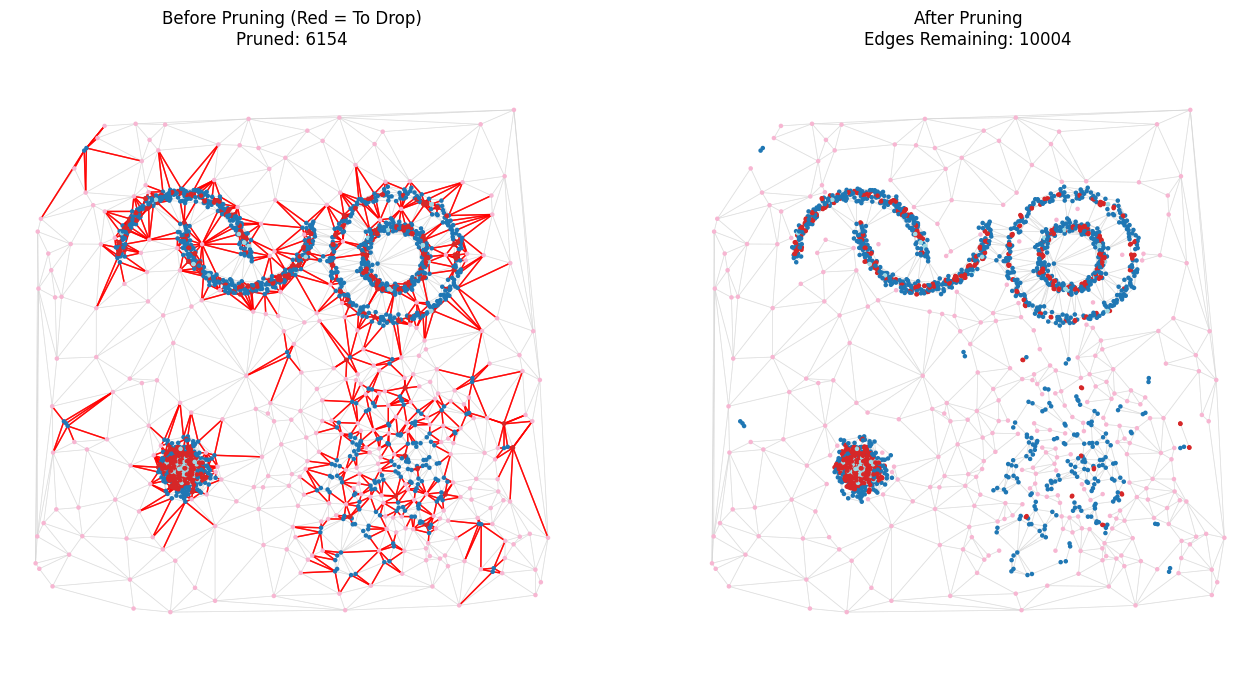

In [28]:
# 1. Compute neighbors (creates 'spatial_connectivities')
graph_utils.get_neighbors(adata, type="delaunay")

# 2. Visualize what WILL be pruned (Must run BEFORE pruning!)
# Visualize Distance Pruning
plot_pruned_connections(
    adata, 
    gmm_key="gmm_labels", 
    prune_by="label",       # <--- Switch to distance mode
    distance_key="1_nn_distance",  # <--- Your distance column
    n_std=4.0,
    mode="comparison"
)
plt.show()

# 3. Now actually prune the graph
# graph_utils.prune_graph(adata, gmm_key="gmm_labels", distance_key="1_nn_distance", prune_by="distance")

In [15]:
graph_utils.prune_graph(adata, gmm_key="gmm_labels")

/home/ktang/Adaptive-Niche/src/graph_utils.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row_label = adata.obs[gmm_key][i]
/home/ktang/Adaptive-Niche/src/graph_utils.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  keep = adata.obs[gmm_key][neigh] == row_label


In [18]:
clustering.watershed_by_descent(adata, distances_key="1_nn_distance", spatial_connectivity_key="pruned_spatial_connectivities")

array([ 382,  301,    1, ..., 1064, 1065, 1034],
      shape=(2700,), dtype=int32)

In [19]:
plotting.assign_colors(sdata, "watershed_by_descent")

In [20]:

adata.obs["watershed_by_descent"].nunique()

1065

# Compare different algorithms

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


Saved plot to niches.png


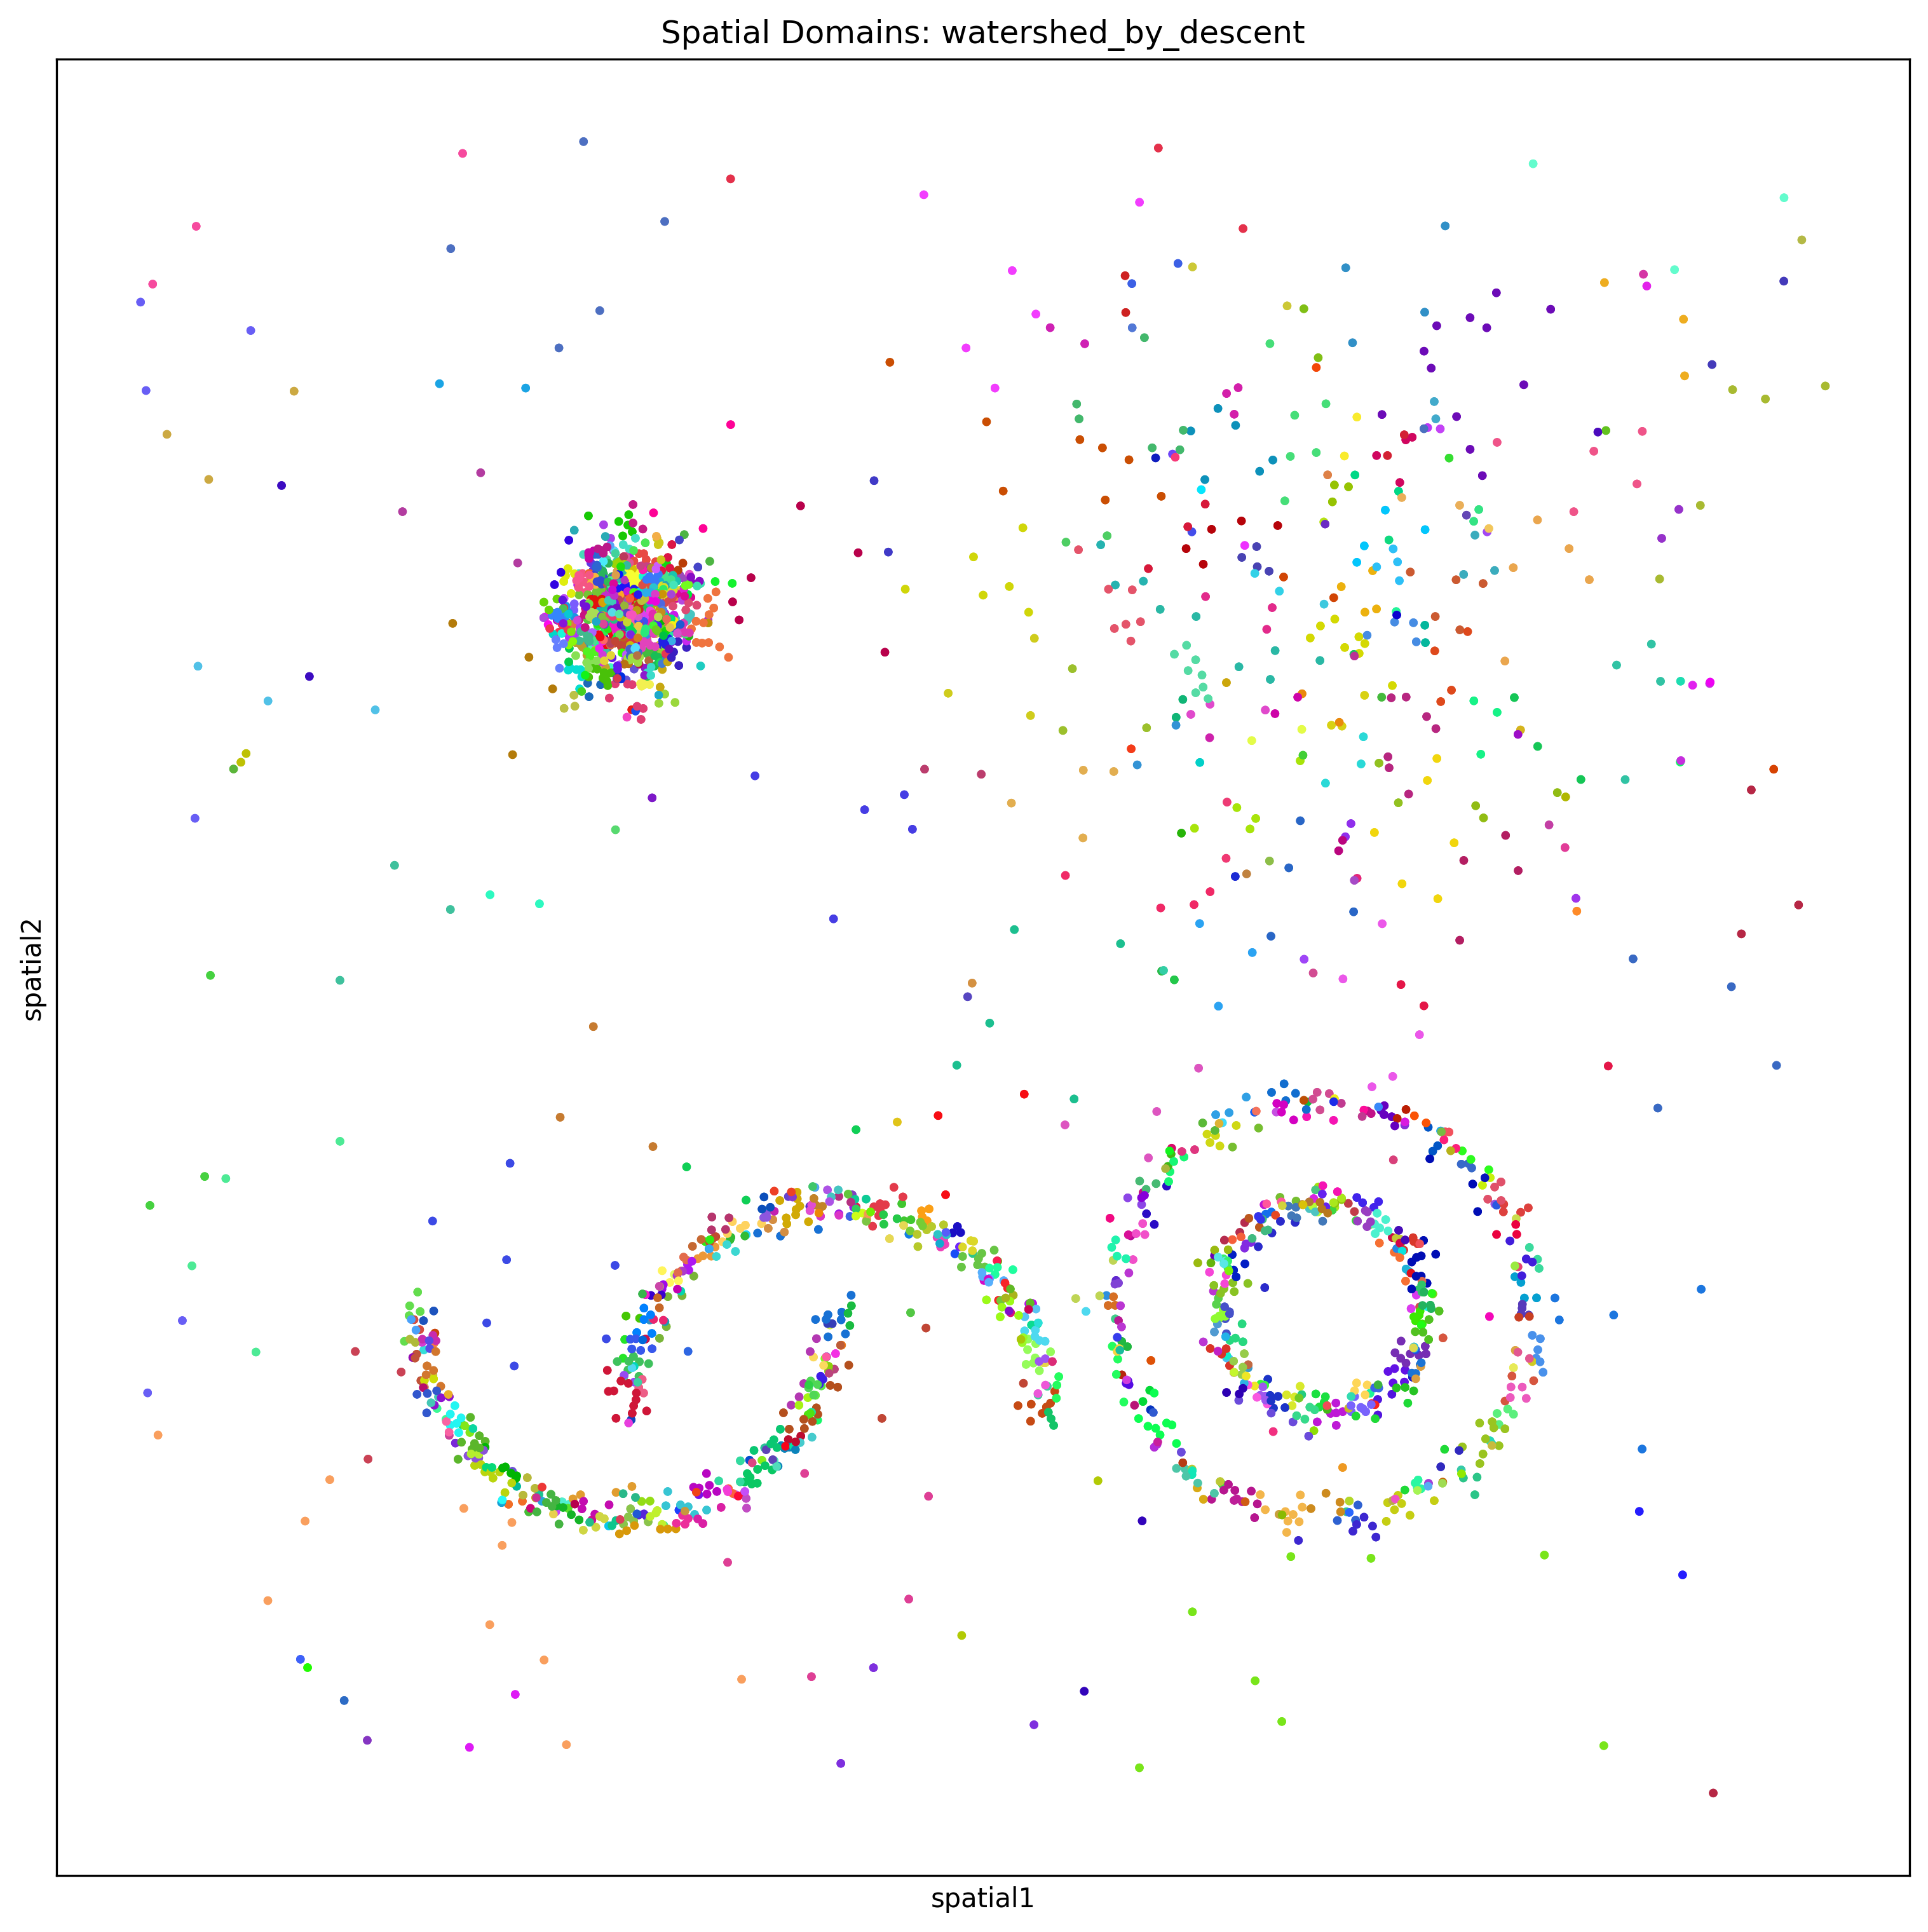

In [22]:
plotting.plot_niches(sdata, niche_key="watershed_by_descent", size=20, output_path="niches.png")

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


Saved plot to niches.png


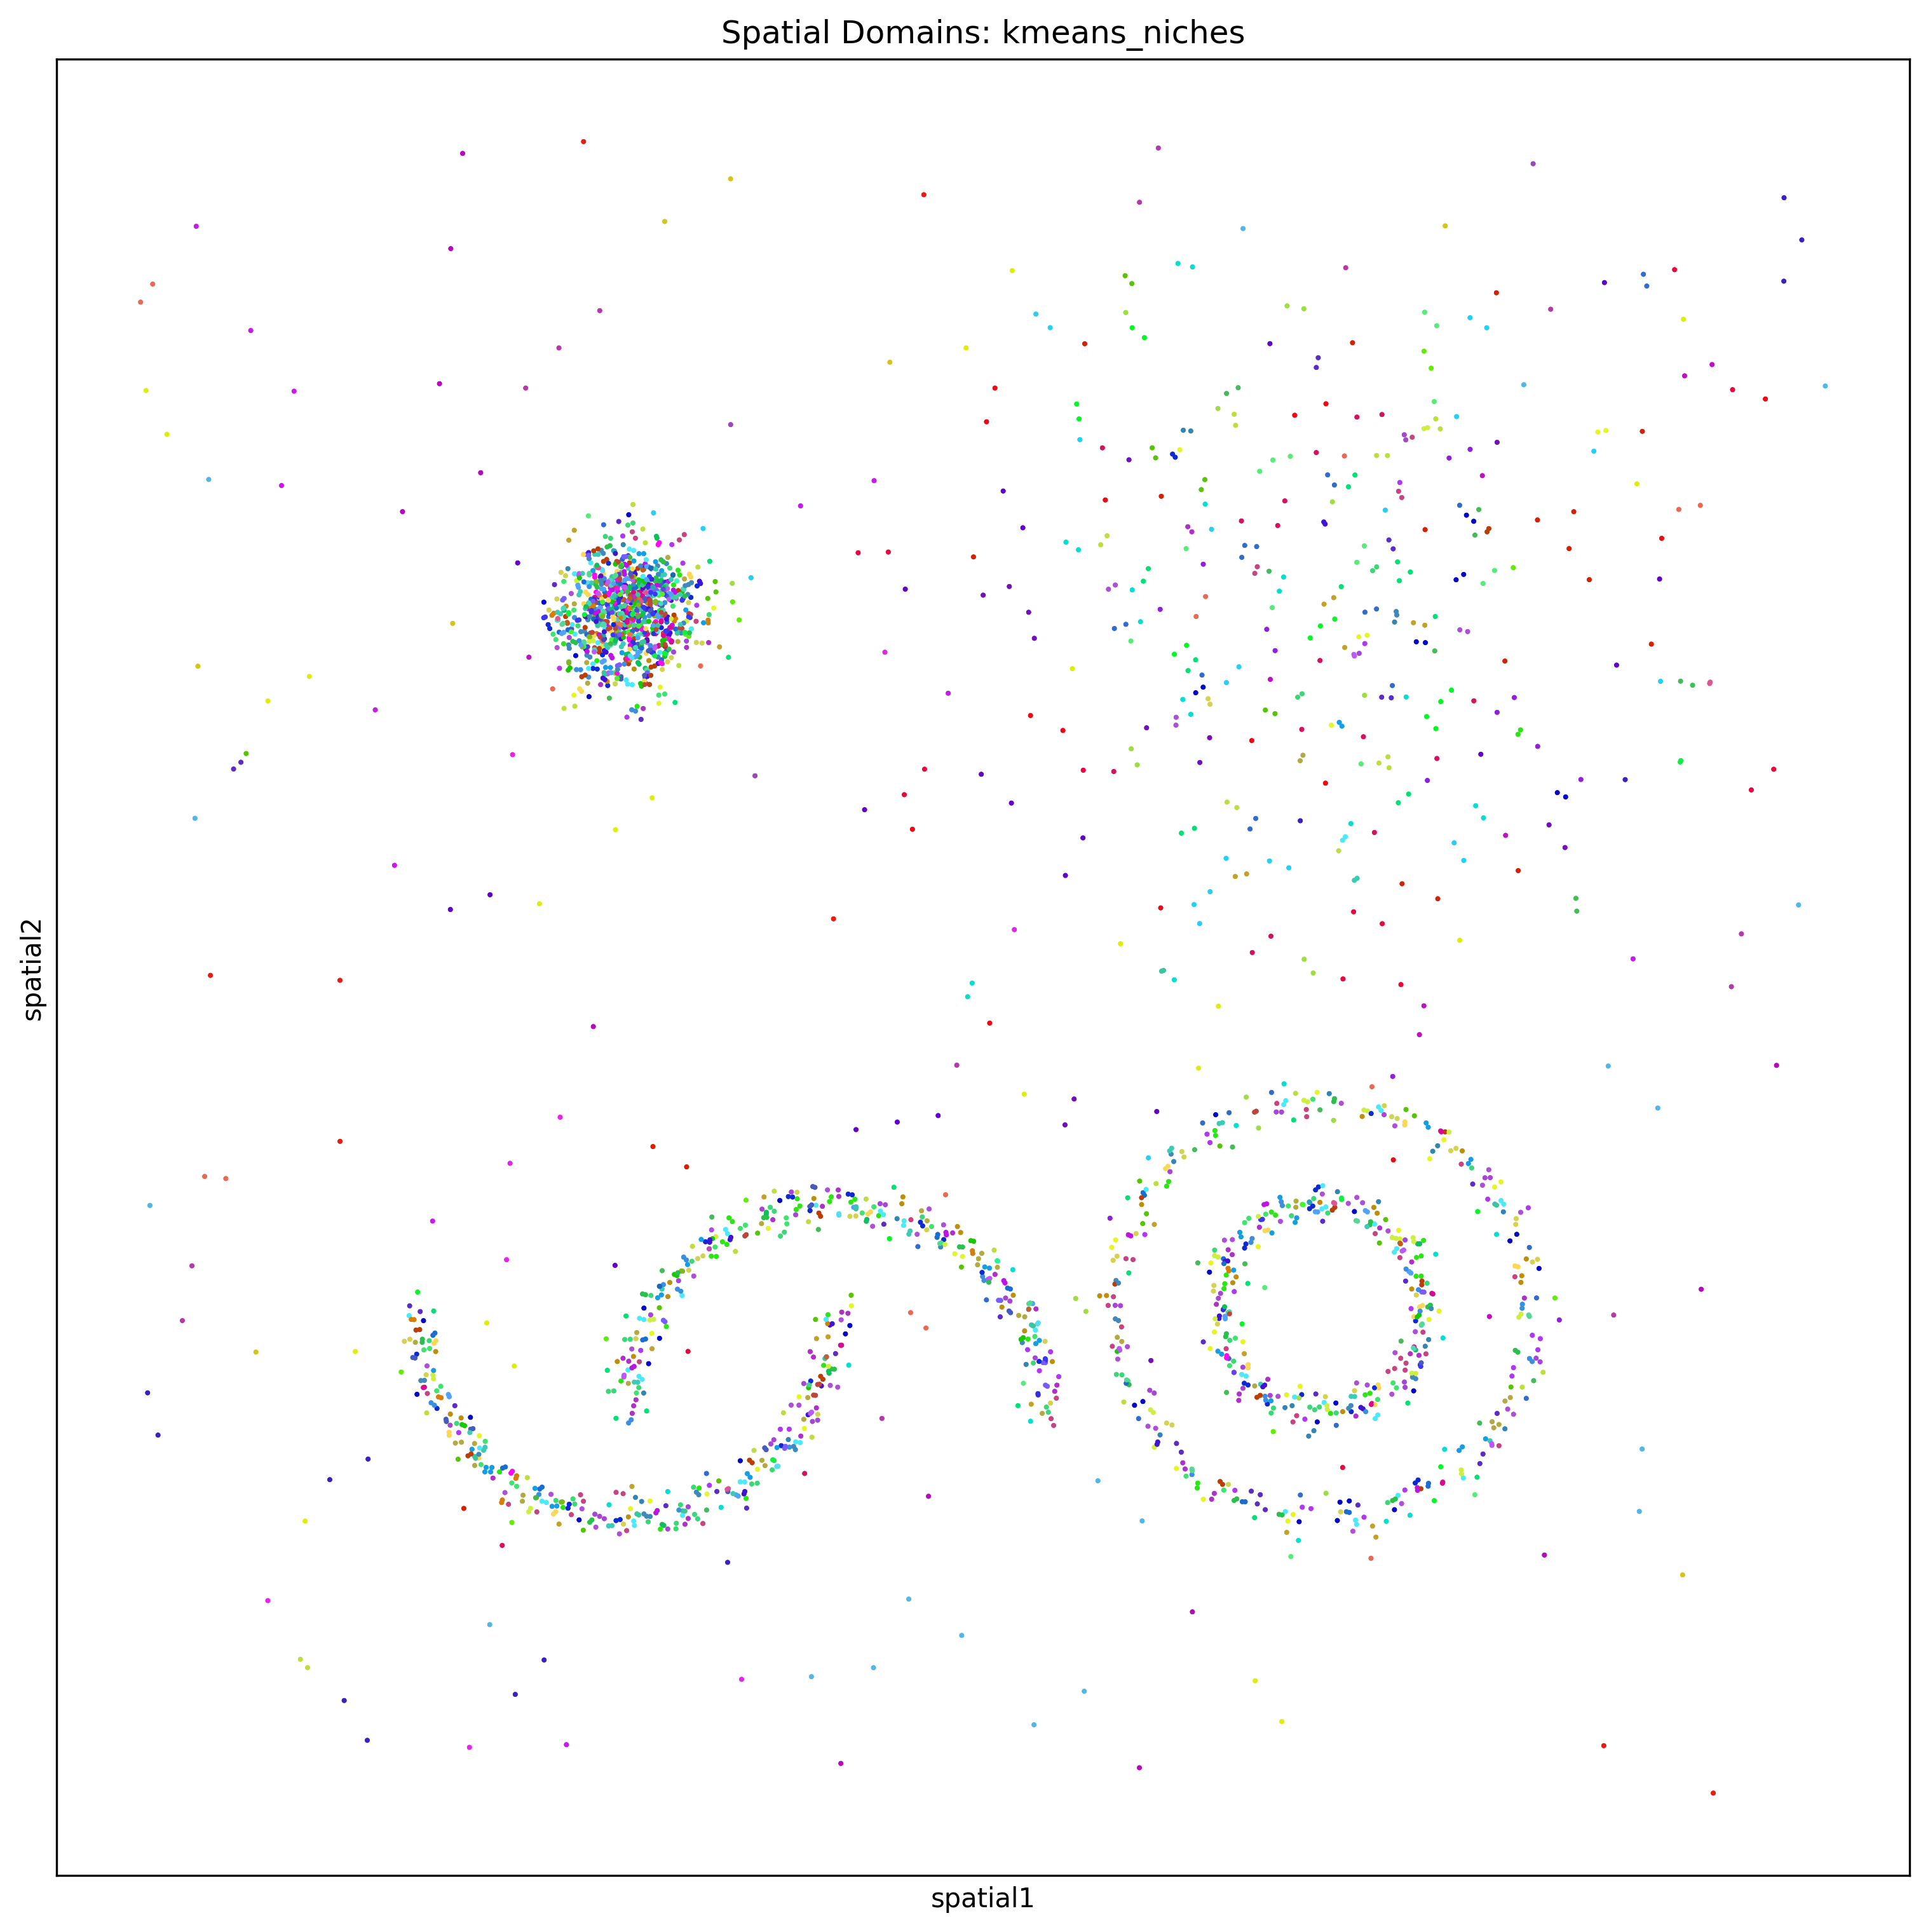

In [14]:
plotting.plot_niches(sdata, niche_key="kmeans_niches", size=3, output_path="niches.png")

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


Saved plot to niches.png


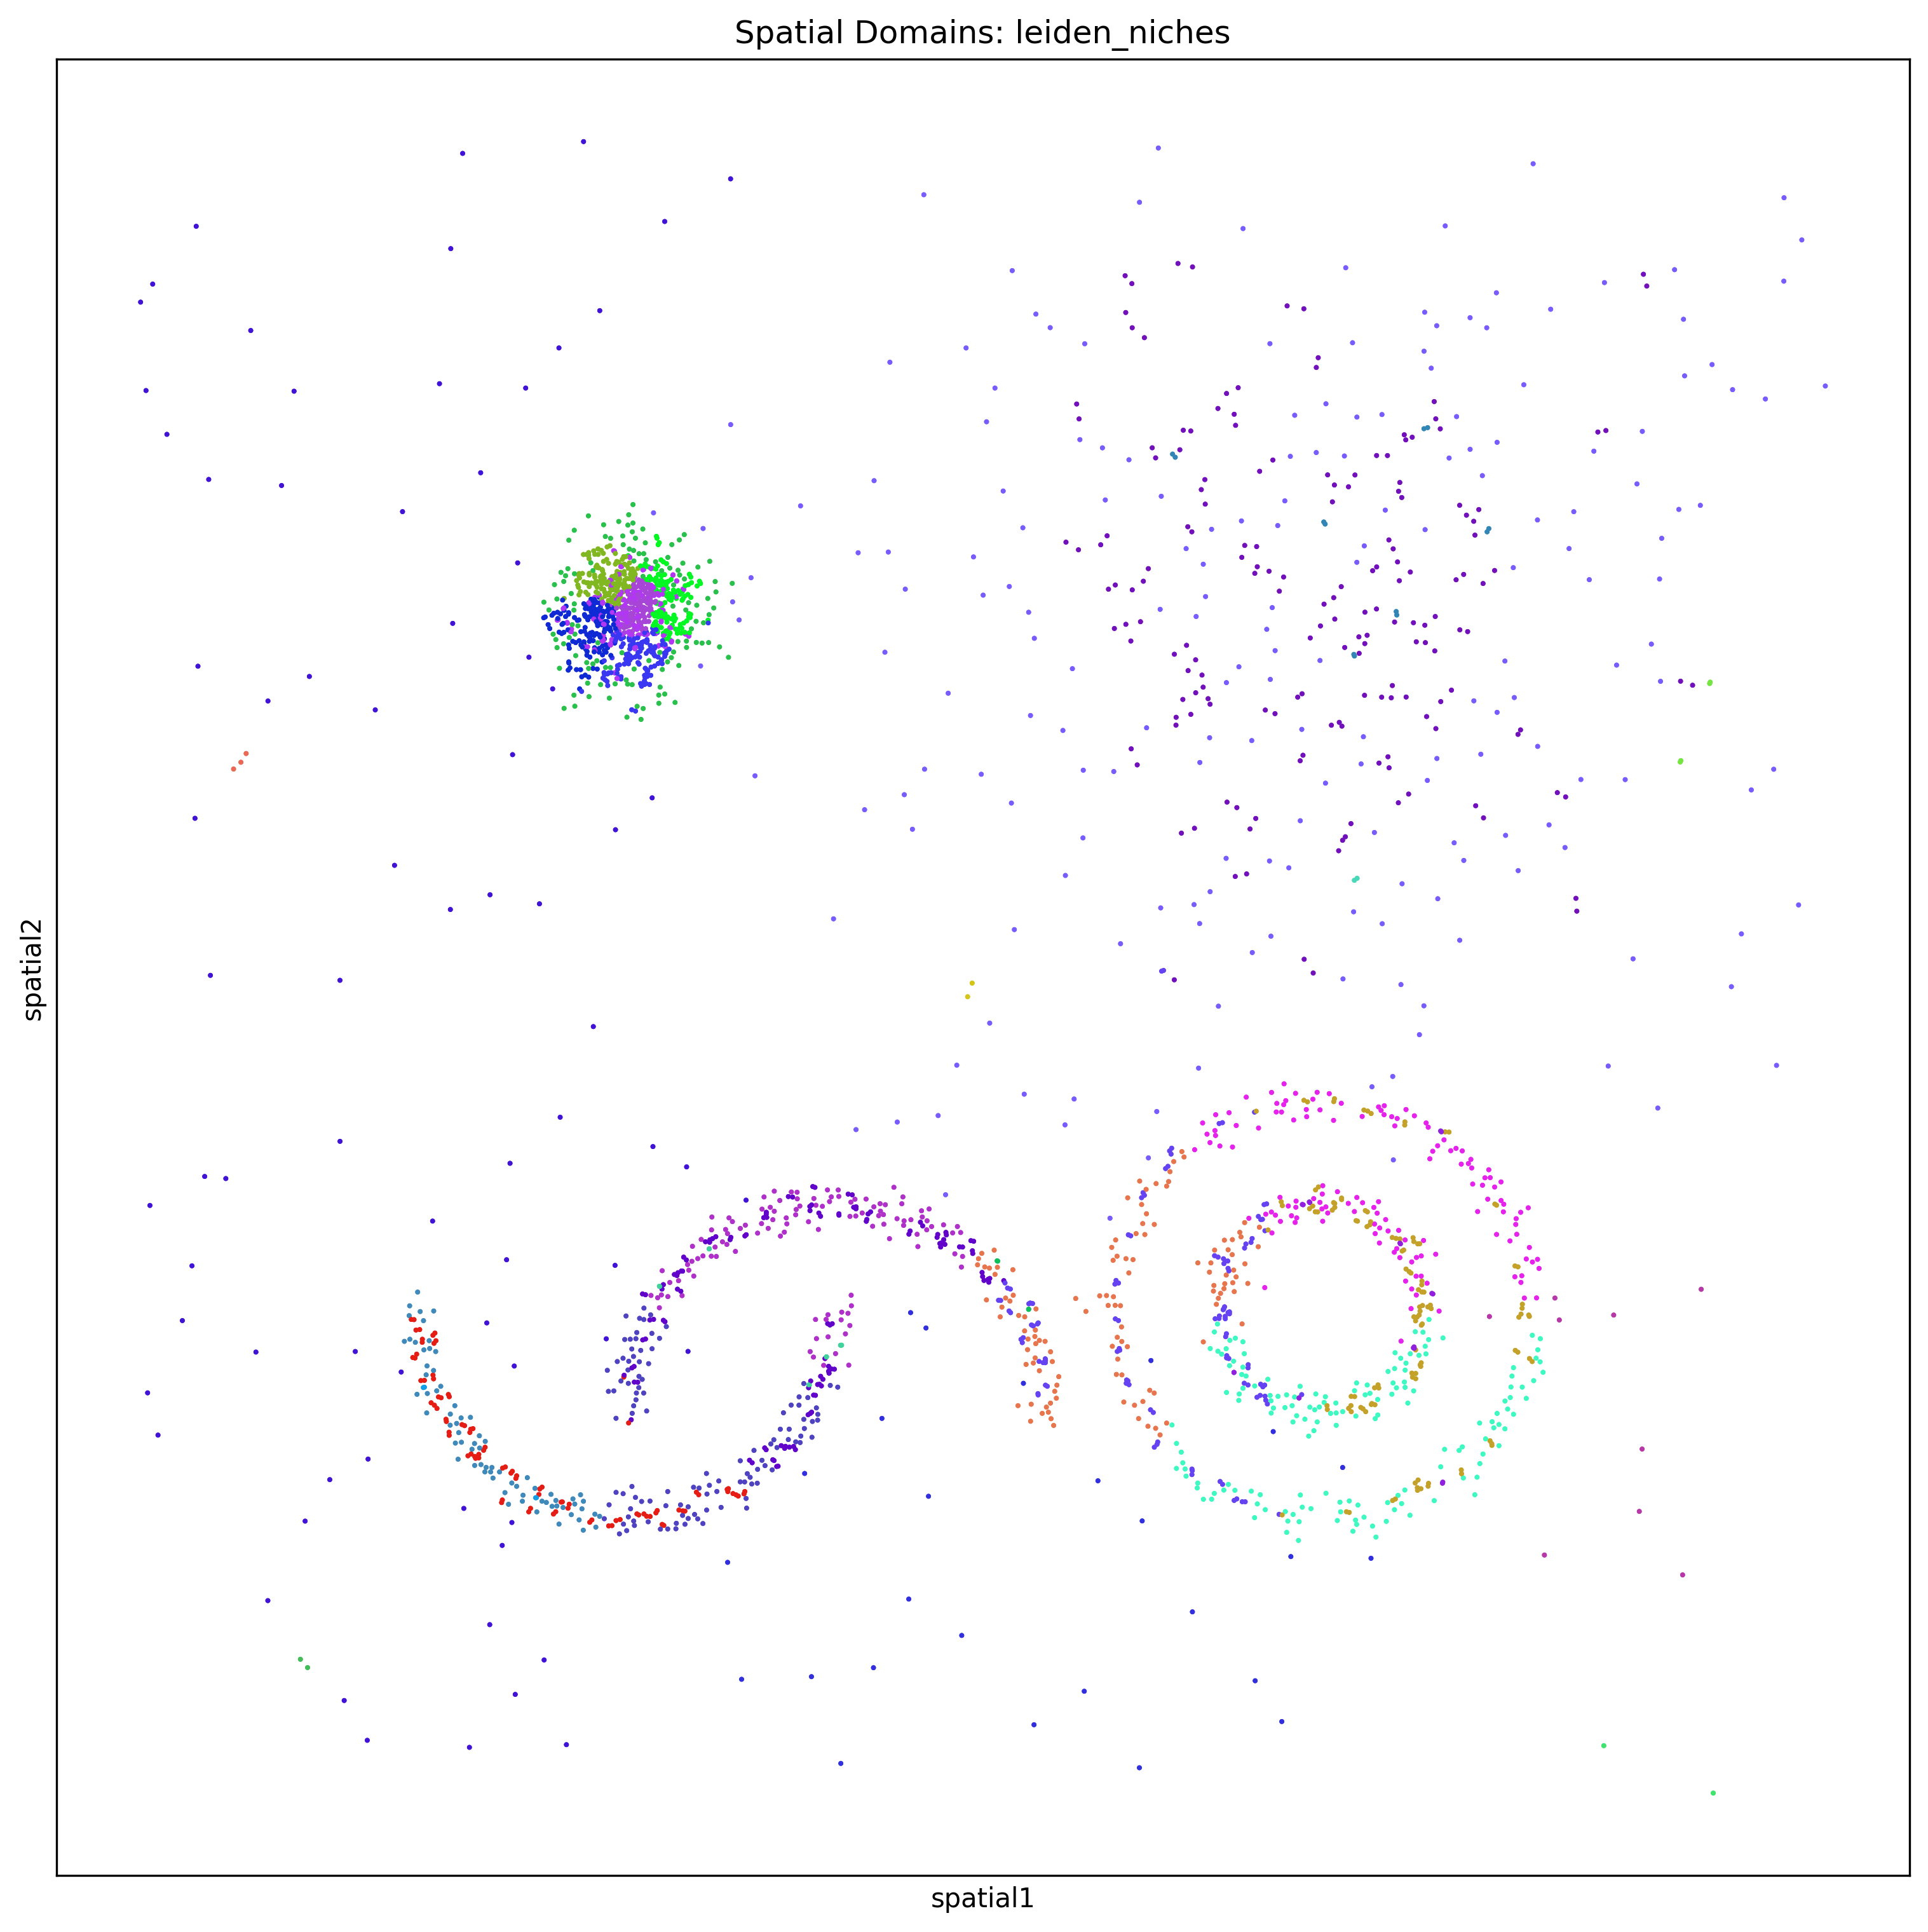

In [15]:
plotting.plot_niches(sdata, niche_key="leiden_niches", size=3, output_path="niches.png")

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


Saved plot to niches.png


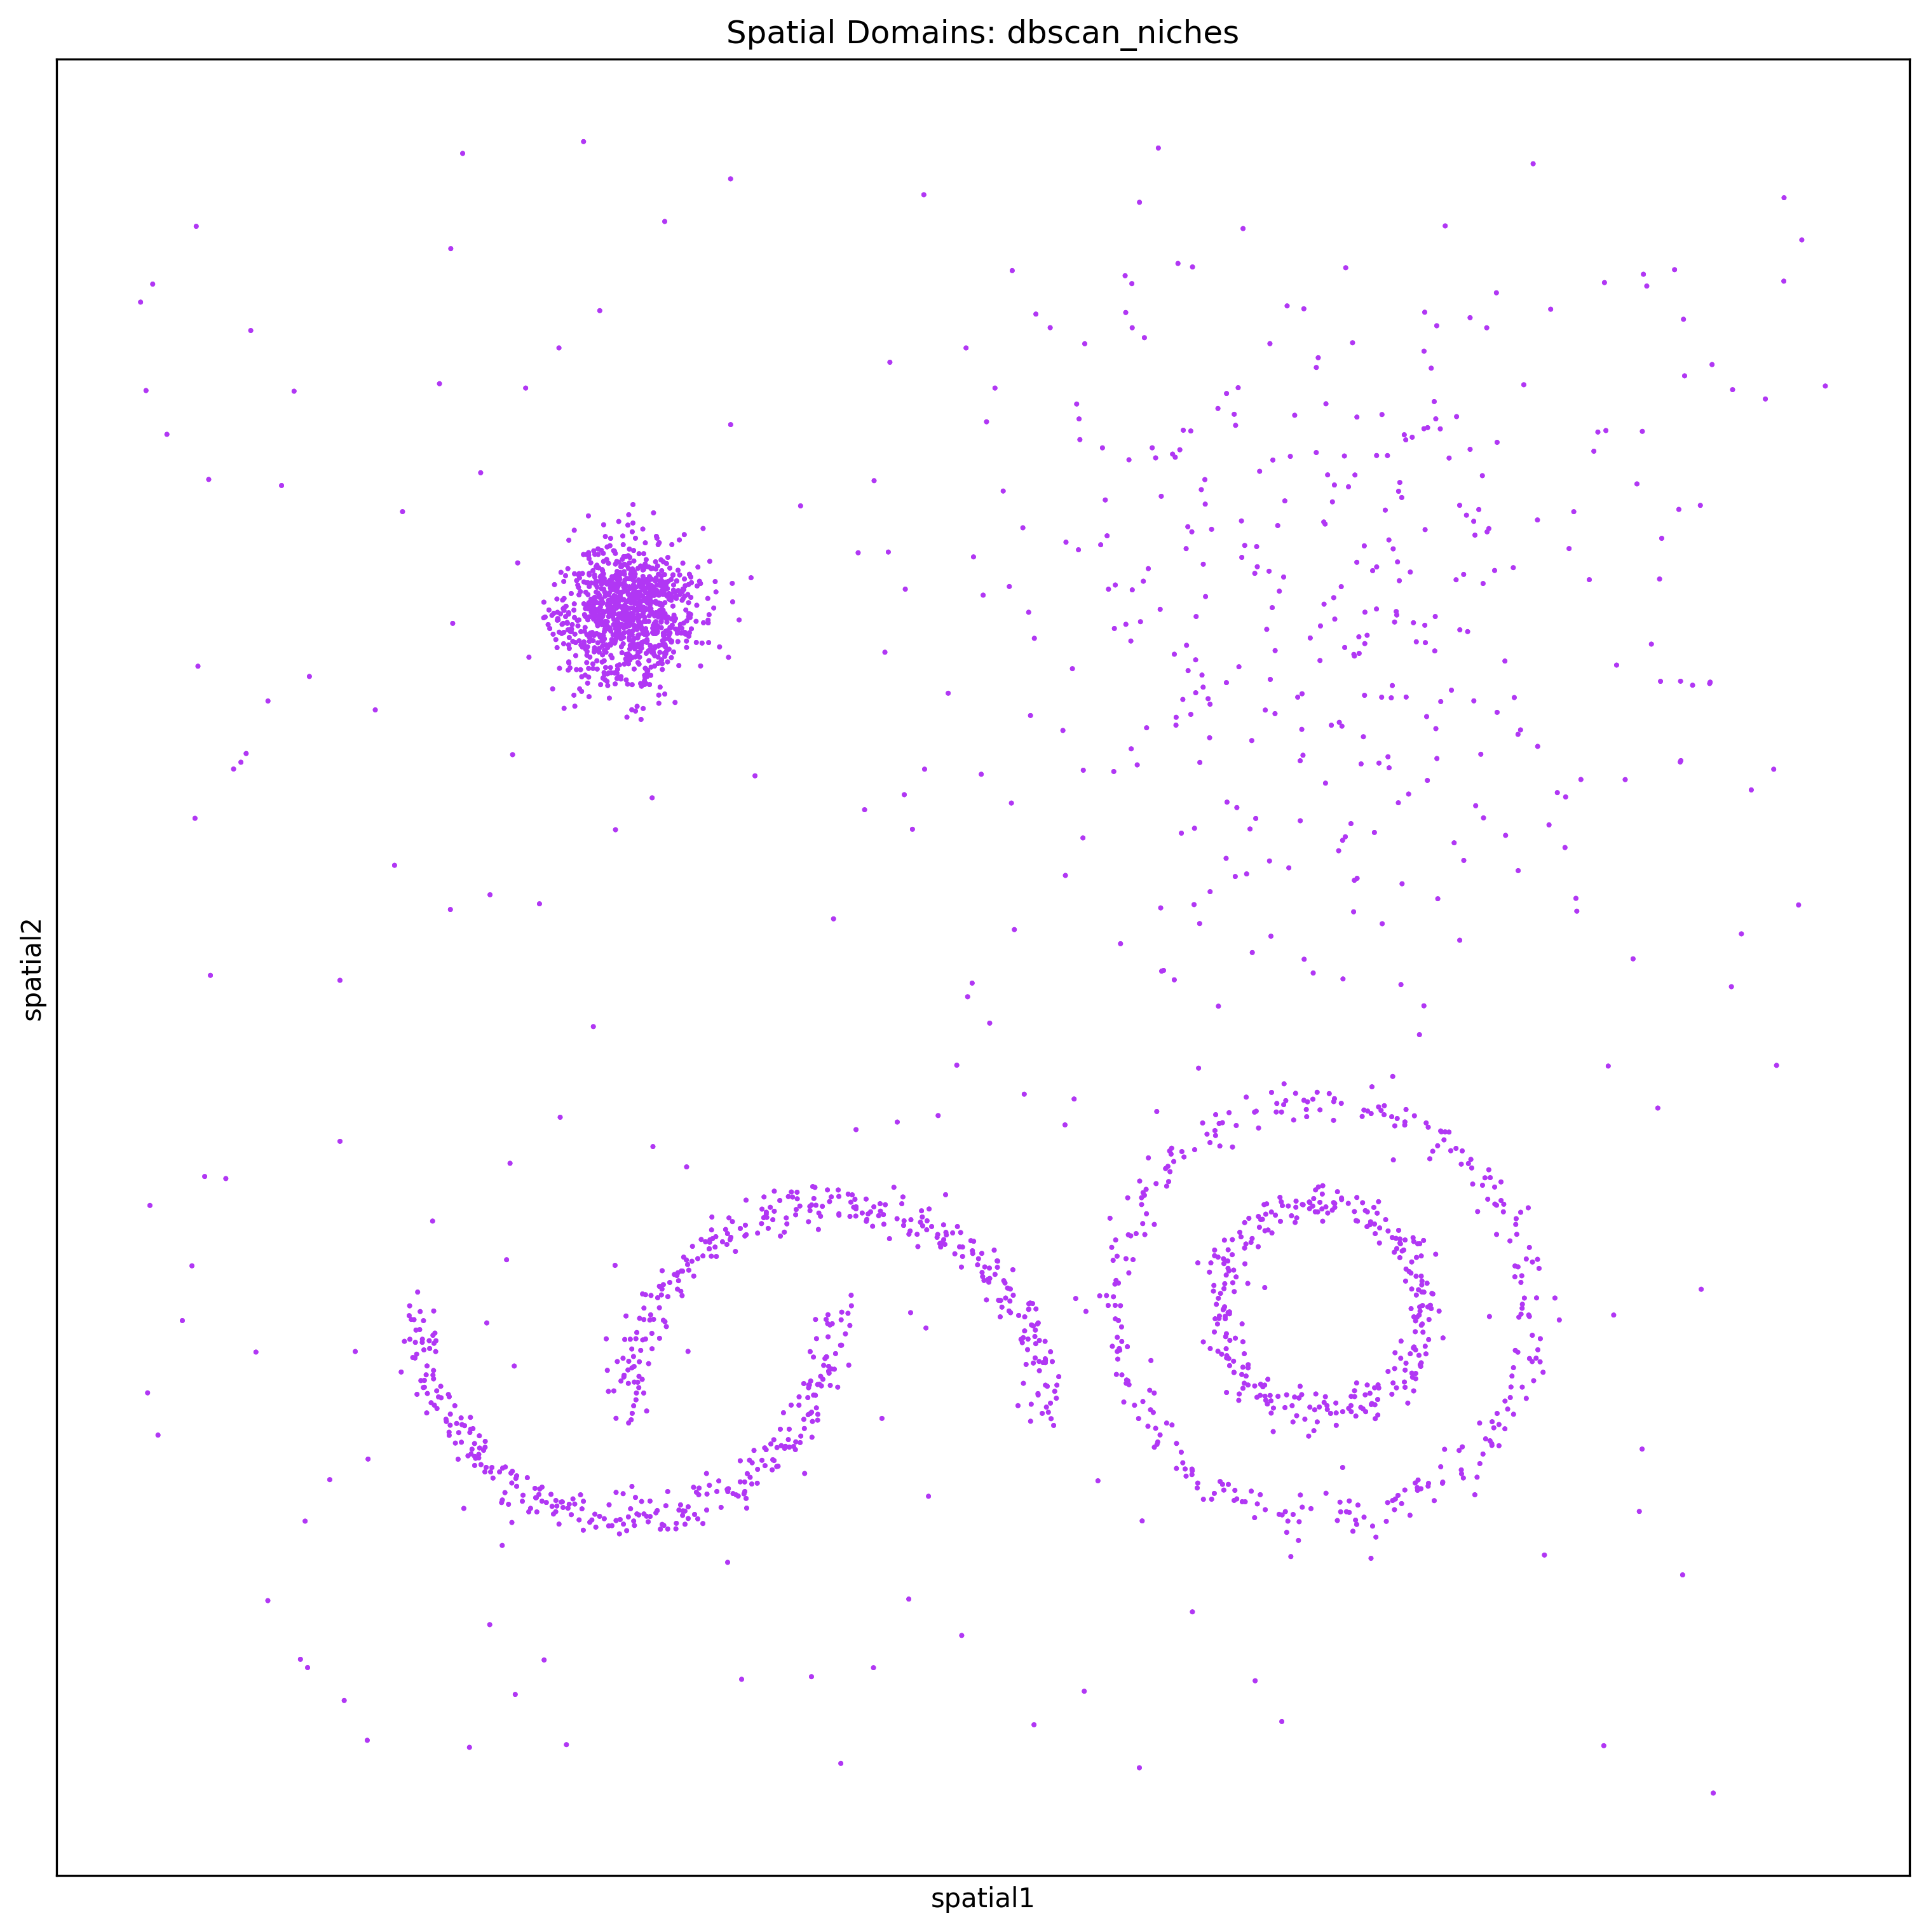

In [21]:
plotting.plot_niches(sdata, niche_key="dbscan_niches", size=3, output_path="niches.png")